**Imports**

In [53]:
import torch
import torch.nn as nn
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import os


**Dataset Download and Loading**

In [54]:
transform=transforms.ToTensor()
train_data=datasets.MNIST(root='./data',train=True,download=True,transform=transform)
test_data=datasets.MNIST(root='./data',train=False,download=True,transform=transform)
train_loader=DataLoader(train_data,64,shuffle=True)
test_loader=DataLoader(test_data,64,shuffle=False)

**Variational Autoencoder Architecture**

In [55]:
class VAE(nn.Module):
  def __init__(self,latent_dim):
    super().__init__()


    self.encoder=nn.Sequential(
        nn.Conv2d(1,32,kernel_size=3,stride=2,padding=1),
        nn.ReLU(),
        nn.Conv2d(32,64,kernel_size=3,stride=2,padding=1),
        nn.ReLU(),
        nn.Flatten(),
        nn.Linear(7*7*64,256),
        nn.ReLU()
    )

    self.mu=nn.Linear(256,latent_dim)
    self.logvar=nn.Linear(256,latent_dim)

    self.decoder=nn.Sequential(
        nn.Linear(latent_dim,256),
        nn.ReLU(),
        nn.Linear(256,7*7*64),
        nn.ReLU(),
        nn.Unflatten(1,(64,7,7)),
        nn.ConvTranspose2d(64,32,kernel_size=4,stride=2,padding=1),
        nn.ConvTranspose2d(32,1,kernel_size=4,stride=2,padding=1),
        nn.Sigmoid()
    )

  def encode(self,x):
    h=self.encoder(x)
    mu=self.mu(h)
    logvar=self.logvar(h)
    return mu,logvar

  # Reparameterization

  def reparameterize(self,mu,logvar):
    std=torch.exp(0.5*logvar)
    eps=torch.randn_like(std)
    return mu+eps*std

  def decode(self,z):
    return self.decoder(z)


  def forward(self,x):
    mu,logvar=self.encode(x)
    z=self.reparameterize(mu,logvar)
    recons=self.decode(z)
    return recons,mu,logvar


**Create Model**

In [56]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

**Loss Function**

In [57]:
# There are two types of loss KL divergence and BCE of real image and recons image
def loss_function(recons,x,mu,logvar):
  recons_loss=nn.functional.binary_cross_entropy(recons,x,reduction='sum')
  kl_div=-0.5*torch.sum(1+logvar-mu.pow(2)-logvar.exp())
  return recons_loss+kl_div

**Initialising the model and hyperparameters**

In [58]:
batch_size = 64
latent_dim = 20
epochs = 40

model = VAE(latent_dim).to(device)
optimizer = optim.Adam(model.parameters(),lr=1e-3)

**Full Training Loop**

In [59]:
for epoch in range(epochs):
  model.train()
  total_loss=0
  for images,_ in train_loader:
    images=images.to(device)
    optimizer.zero_grad()
    reconstructed,mu,logvar=model(images)
    loss=loss_function(reconstructed,images,mu,logvar)
    loss.backward()
    optimizer.step()
    total_loss += loss.item()

  print(f'Epoch {epoch+1}, Loss: {total_loss / len(train_loader.dataset)}')


Epoch 1, Loss: 151.21580913492838
Epoch 2, Loss: 113.81414560546875
Epoch 3, Loss: 108.0932081217448
Epoch 4, Loss: 105.61458303629557
Epoch 5, Loss: 104.15498334147135
Epoch 6, Loss: 103.20950684814453
Epoch 7, Loss: 102.55510233154297
Epoch 8, Loss: 101.98420972086589
Epoch 9, Loss: 101.51167322184244
Epoch 10, Loss: 101.13785861002604
Epoch 11, Loss: 100.74329206542969
Epoch 12, Loss: 100.44561682128906
Epoch 13, Loss: 100.19193943277995
Epoch 14, Loss: 99.92872868245443
Epoch 15, Loss: 99.71622791748047
Epoch 16, Loss: 99.47800229085287
Epoch 17, Loss: 99.28927543945312
Epoch 18, Loss: 99.10545930582683
Epoch 19, Loss: 98.97619287923177
Epoch 20, Loss: 98.77194202067058
Epoch 21, Loss: 98.64653653157552
Epoch 22, Loss: 98.56098643798828
Epoch 23, Loss: 98.4436384358724
Epoch 24, Loss: 98.26381470947265
Epoch 25, Loss: 98.1976440633138
Epoch 26, Loss: 98.06615310058594
Epoch 27, Loss: 97.97998306884766
Epoch 28, Loss: 97.85885914713542
Epoch 29, Loss: 97.74908477783202
Epoch 30, Los

**Evaluation and Visualization**

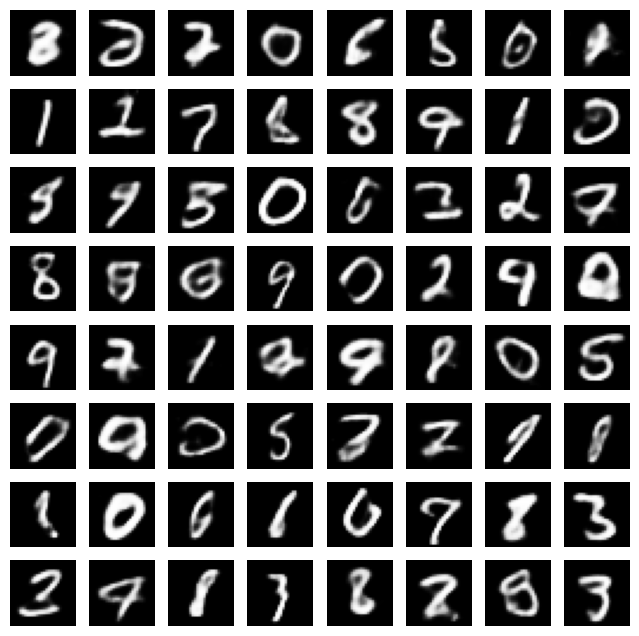

In [60]:
model.eval()
with torch.no_grad():
    z = torch.randn(64, latent_dim).to(device)
    generated_images = model.decode(z).cpu()

# Visualize generated images
fig, axes = plt.subplots(8, 8, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated_images[i].squeeze(), cmap='gray')
    ax.axis('off')
plt.show()

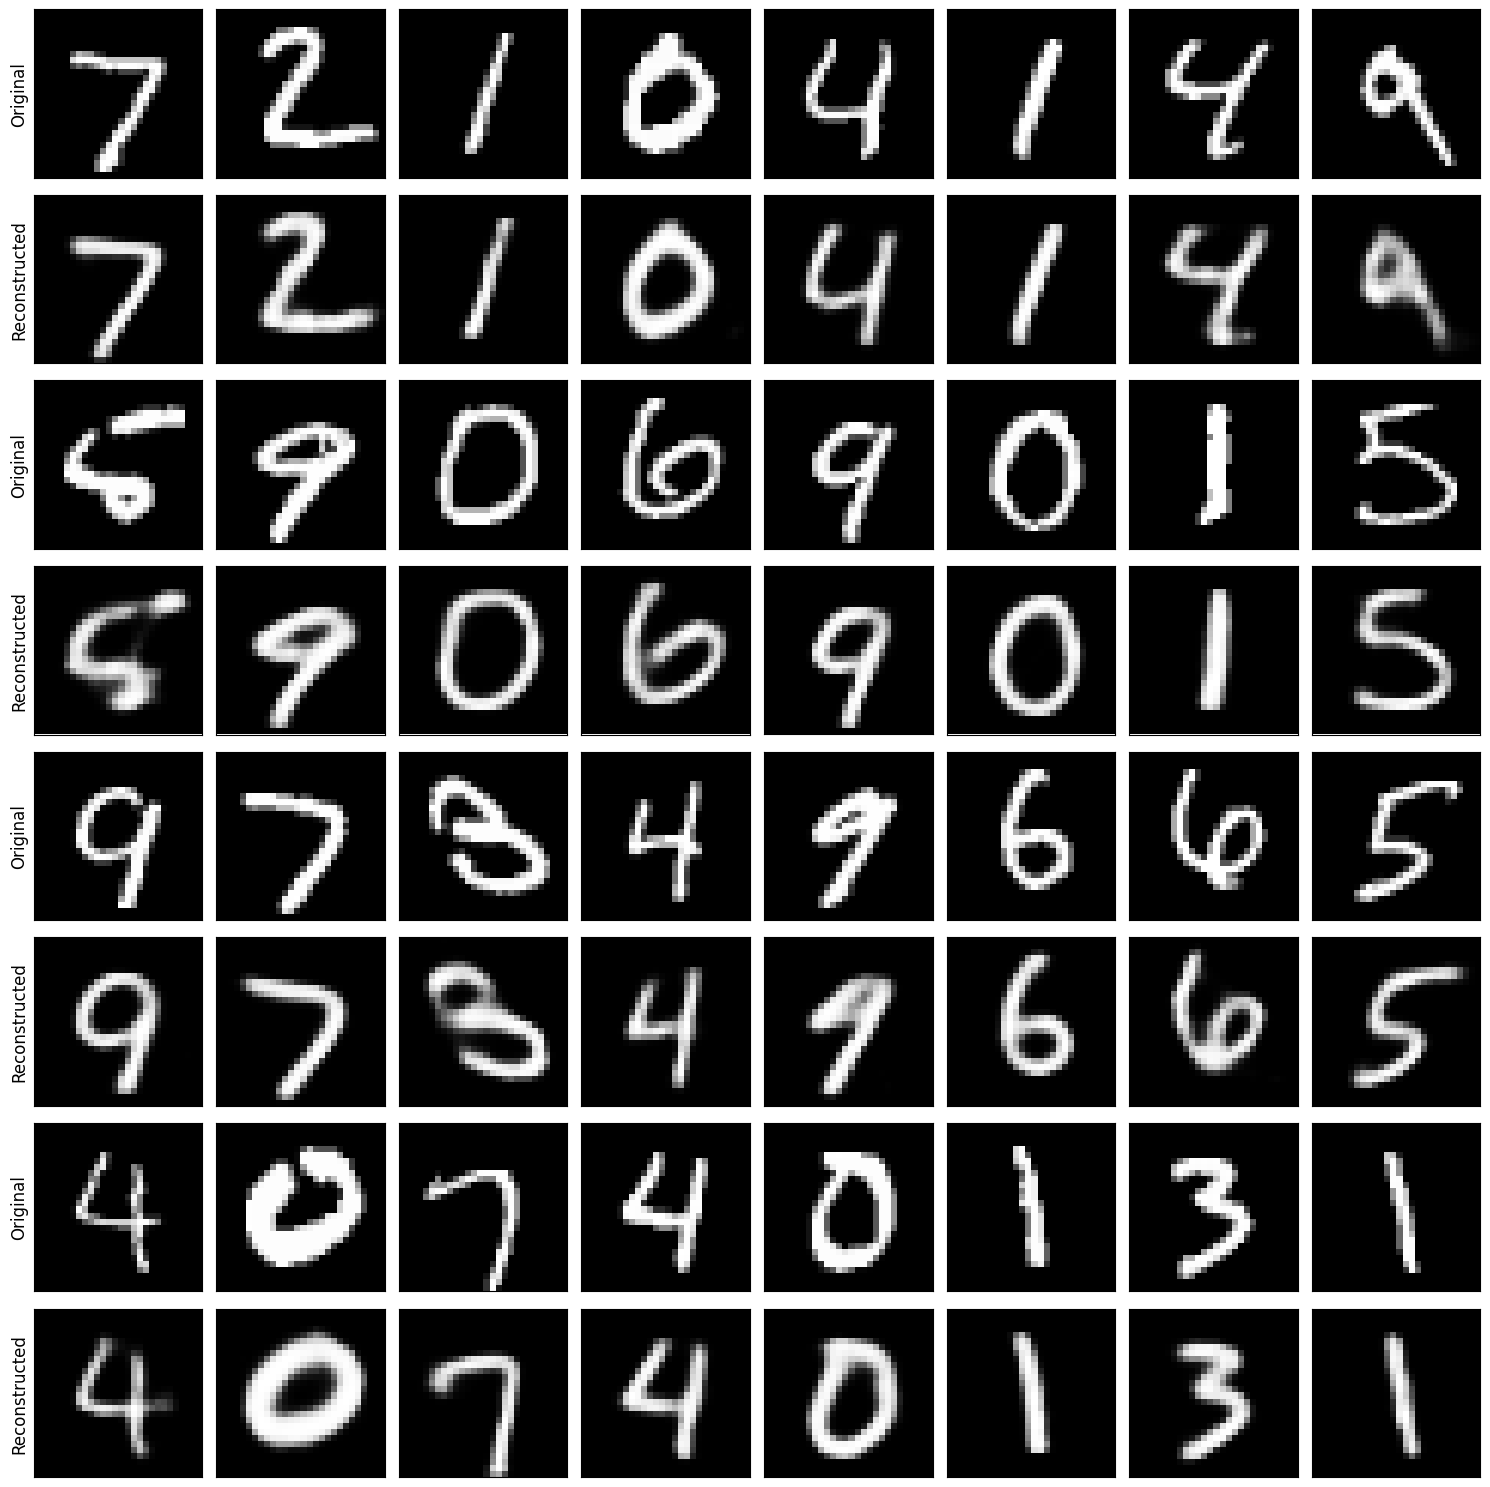

In [63]:
test_images, _ = next(iter(test_loader))
test_images = test_images.to(device)

model.eval()
with torch.no_grad():
    recon_images, _, _ = model(test_images)

originals = test_images.cpu()
recons = recon_images.cpu()

n_cols = 8
n_pairs = 4

fig, axes = plt.subplots(n_pairs * 2, n_cols, figsize=(15, 15))

for pair in range(n_pairs):
    for col in range(n_cols):
        idx = pair * n_cols + col

        top = axes[pair * 2][col]
        bottom = axes[pair * 2 + 1][col]

        top.imshow(originals[idx].squeeze(), cmap='gray')
        bottom.imshow(recons[idx].squeeze(), cmap='gray')

        if col == 0:
            top.set_ylabel("Original", fontsize=12)
            bottom.set_ylabel("Reconstructed", fontsize=12)

        top.set_xticks([]); top.set_yticks([])
        bottom.set_xticks([]); bottom.set_yticks([])

plt.tight_layout()
plt.show()

In [64]:
torch.save(
    model.state_dict(),
    "vae_mnist.pth"
)

print("Model saved successfully")

Model saved successfully


In [66]:
from google.colab import files
files.download("vae_mnist.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>